# 01.2 — Distribution Shape & Intermittency Analysis

Phân tích hình thái phân phối (độ lệch, độ nhọn) và các chỉ số ngắt quãng ADI/CV^2 của chuỗi lượng mưa.


In [1]:
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reconfigure encoding
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')

# Path resolution
ROOT_DIR = Path.cwd()
while not (ROOT_DIR / "src").exists() and ROOT_DIR != ROOT_DIR.parent:
    ROOT_DIR = ROOT_DIR.parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.data.loader import DataLoader, time_series_split
from src.eda.DistributionAnalysis import DistributionAnalyzer, interpret_intermittency

# 1. Nạp Train data và ngưỡng mưa đã xác lập từ Notebook 02.1
df = DataLoader().load_data()
train_df, _ = time_series_split(df)

threshold_path = ROOT_DIR / "notebooks" / "eda" / "outputs" / "threshold_report.json"
if threshold_path.exists():
    with open(threshold_path, "r", encoding="utf-8") as f:
        th_data = json.load(f)
    RAIN_THRESHOLD = th_data.get("chosen_threshold_mm", 0.1)
else:
    RAIN_THRESHOLD = 0.1

print(f"📊 Phân tích Phân phối & Tính Gián đoạn (Train Set: {len(train_df):,} ngày)")
print(f"   • Ngưỡng mưa tiêu thụ từ 02.1: tau = {RAIN_THRESHOLD} mm")

# 2. Chạy DistributionAnalyzer
dist_analyzer = DistributionAnalyzer(train_df, target_col='Lượng mưa')
dist_results = dist_analyzer.analyze()

interm = dist_results['intermittency']
desc_stats = dist_results.get('descriptive_stats', {})
skew_val = float(train_df['Lượng mưa'].skew())
kurt_val = float(train_df['Lượng mưa'].kurt())

print("\n📈 THỐNG SỐ HÌNH THÁI PHÂN PHỐI & GIÁN ĐOẠN:")
print(f"   • Skewness (Độ lệch):                {skew_val:.2f} (Lệch phải cực đoan)")
print(f"   • Kurtosis (Độ nhọn):                {kurt_val:.2f} (Đuôi nặng Leptokurtic)")
print(f"   • ADI (Average Demand Interval):     {interm['adi']:.2f} ngày (Ngưỡng lý thuyết 1.32)")
print(f"   • CV² (Squared Coeff of Variation):  {interm['cv2']:.2f} (Ngưỡng lý thuyết 0.49)")
print(f"   • Cường độ mưa TB ngày mưa:          {interm['mean_rain_intensity_mm']:.2f} mm/ngày")
print(f"   • Khoảng cách trung vị giữa các đợt: {interm['median_interval_days']:.1f} ngày")

ref_label = interpret_intermittency(interm['adi'], interm['cv2'])
print(f"   • Phân loại Syntetos-Boylan:         {ref_label['classification']}")


📊 Phân tích Phân phối & Tính Gián đoạn (Train Set: 7,060 ngày)
   • Ngưỡng mưa tiêu thụ từ 02.1: tau = 0.1 mm
📊 DISTRIBUTION ANALYSIS INITIALIZED
   - Total Features: 35
   - Analysis Features: 35
   - Target Variable: Lượng mưa
   - Sample Size: 7,060

📈 1. DESCRIPTIVE STATISTICS SUMMARY
📊 Comprehensive Descriptive Statistics:

🔢 Basic Statistics:
                    Feature  Count     Mean   Median     Mode     Std     Min      Max
    Bức xạ sóng ngắn bề mặt   7060   5.2073   5.3209   5.8164  1.0245  0.8422   7.4844
Bức xạ sóng ngắn trời quang   7060   6.6736   6.8480   7.0034  0.4849  4.8514   7.6896
Bức xạ trực tiếp pháp tuyến   7060   3.5814   3.6803   0.1603  1.9915  0.0038   8.4108
          Bức xạ khuếch tán   7060   2.3811   2.3709   2.1578  0.4898  0.5669   3.9511
      Bức xạ đỉnh khí quyển   7060   9.8210  10.2396  10.3817  0.6815  8.4977  10.5242
      Bức xạ quang hợp tổng   7060   2.4563   2.5086   2.3705  0.4608  0.4428   3.4716
Bức xạ quang hợp trời quang   7060   3.1

🎨 Trực quan hóa hình thái phân phối Lượng mưa:


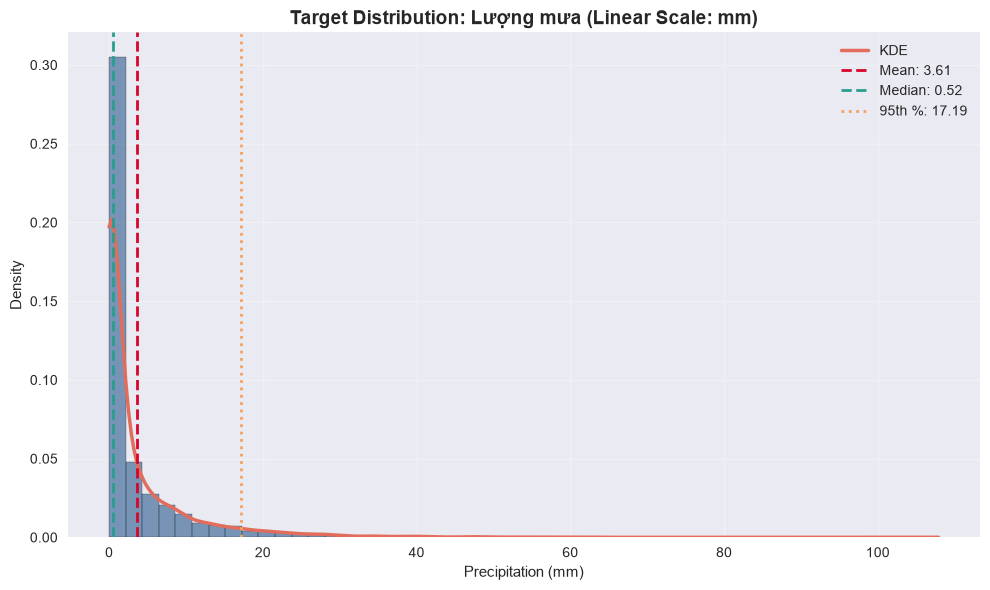

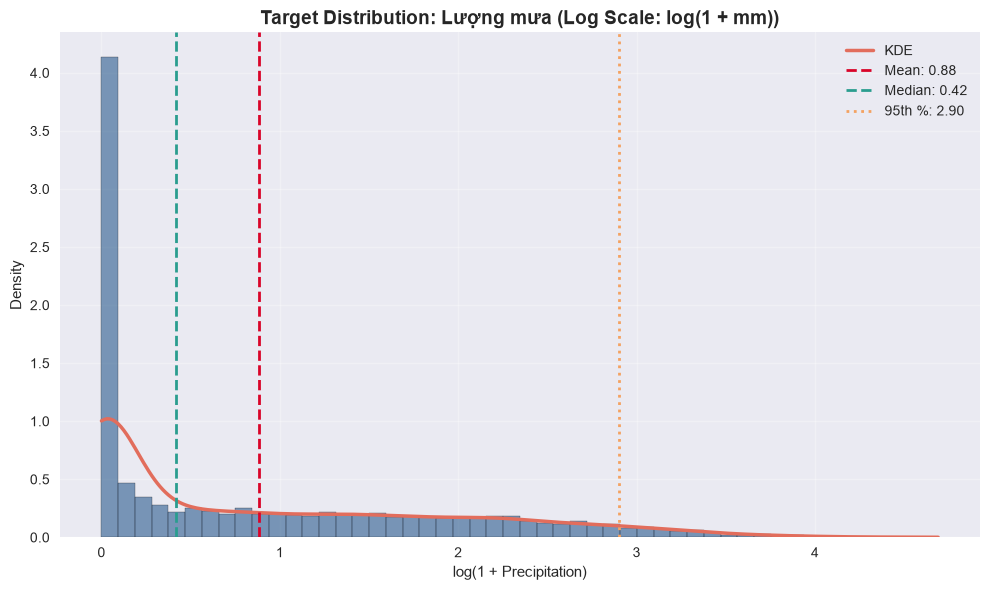

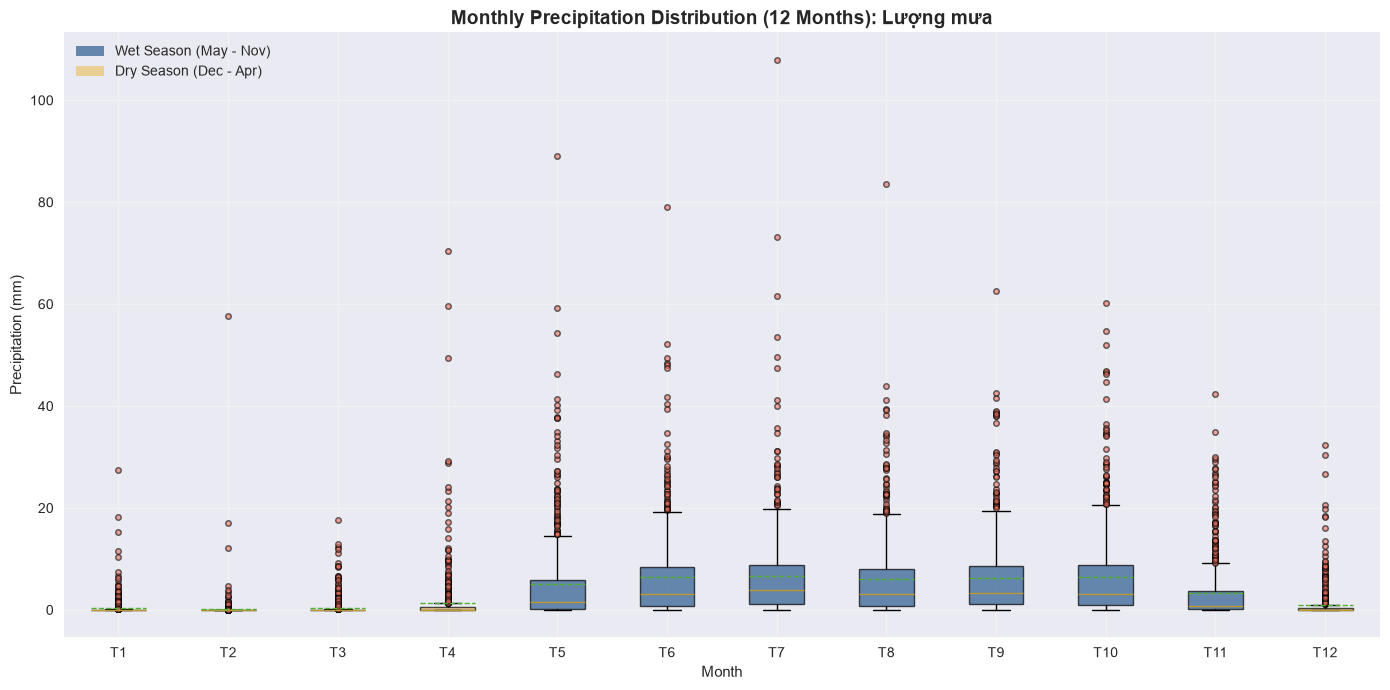

In [2]:
# 3. Trực quan hóa Phân phối: Tuyến tính, Log1p, và 12 Tháng
print("🎨 Trực quan hóa hình thái phân phối Lượng mưa:")

# Panel 1: Histogram + KDE (Thang tuyến tính)
fig_lin = dist_analyzer.plot_target_histogram_kde(log_scale=False, return_fig=True)
plt.show()

# Panel 2: Histogram + KDE (Thang Log1p: log(1 + y))
fig_log = dist_analyzer.plot_target_histogram_kde(log_scale=True, return_fig=True)
plt.show()

# Panel 3: Monthly Boxplot qua 12 tháng
fig_mon = dist_analyzer.plot_monthly_distribution(date_col='Ngày', return_fig=True)
plt.show()


In [3]:
# 4. Tìm các đặc trưng có độ lệch cao (|skew| > 2) trong tập dữ liệu
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
high_skew_cols = [c for c in numeric_cols if abs(train_df[c].dropna().skew()) > 2.0]

print(f"📊 Danh sách đặc trưng có Skewness cao (|skew| > 2):")
for col in high_skew_cols:
    print(f"   • {col}: skew = {train_df[col].skew():.2f}")

# 5. Xuất Artifact distribution_report.json
OUTPUT_DIR = ROOT_DIR / "notebooks" / "eda" / "outputs"
DATA_OUTPUT_DIR = ROOT_DIR / "data" / "processed" / "eda_outputs"

dist_artifact = {
    "target_variable": "Lượng mưa",
    "rainfall_threshold_used_mm": RAIN_THRESHOLD,
    "skewness": round(skew_val, 4),
    "kurtosis": round(kurt_val, 4),
    "distribution_type": "Zero-inflated, highly right-skewed, leptokurtic tail",
    "intermittency": {
        "adi": round(float(interm['adi']), 4),
        "cv2": round(float(interm['cv2']), 4),
        "classification": ref_label['classification'],
        "rain_day_pct": round(float(interm['rain_day_pct']), 4),
        "n_rain_events": int(interm['n_rain_events']),
        "mean_rain_intensity_mm": round(float(interm['mean_rain_intensity_mm']), 4),
        "median_interval_days": round(float(interm['median_interval_days']), 4)
    },
    "high_skew_features": high_skew_cols,
    "scientific_implication": "Lumpy intermittent demand justifies Two-Stage Hurdle and Tweedie Compound Poisson models over standard OLS regression."
}

artifact_path = OUTPUT_DIR / "distribution_report.json"
with open(artifact_path, "w", encoding="utf-8") as f:
    json.dump(dist_artifact, f, indent=2, ensure_ascii=False)

with open(DATA_OUTPUT_DIR / "distribution_report.json", "w", encoding="utf-8") as f:
    json.dump(dist_artifact, f, indent=2, ensure_ascii=False)

print(f"\n💾 Distribution report exported to: {artifact_path}")
print(f"   • Phân loại chuỗi: {dist_artifact['intermittency']['classification']} (ADI={dist_artifact['intermittency']['adi']}, CV2={dist_artifact['intermittency']['cv2']})")


📊 Danh sách đặc trưng có Skewness cao (|skew| > 2):
   • Lượng mưa: skew = 4.06

💾 Distribution report exported to: D:\DS108_project\notebooks\eda\outputs\distribution_report.json
   • Phân loại chuỗi: LUMPY (ADI=1.6516, CV2=1.9923)
